ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [1]:
import seaborn as sns  # imports the Seaborn visualization library and gives it the short name sns

%matplotlib inline 
# (Jupyter only) displays plots directly inside the notebook output
 

## Data
Seaborn comes with built-in data sets!

In [2]:
tips = sns.load_dataset('tips')  # loads Seaborn's built-in "tips" dataset into a DataFrame

tips.head()  # shows the first 5 rows of the tips dataset

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

<Axes: xlabel='total_bill', ylabel='Count'>

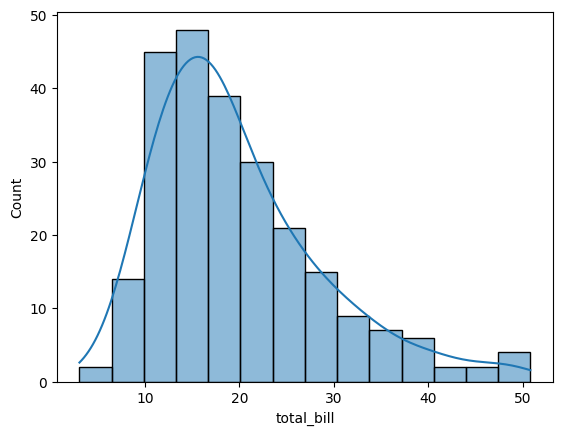

In [5]:
sns.histplot(tips['total_bill'], kde=True) # plots the distribution of the total_bill values (histogram + KDE curve by default)

# Safe to ignore warnings  # notes that any warnings shown here are not critical



To remove the kde layer and just have the histogram use:

<Axes: xlabel='total_bill', ylabel='Count'>

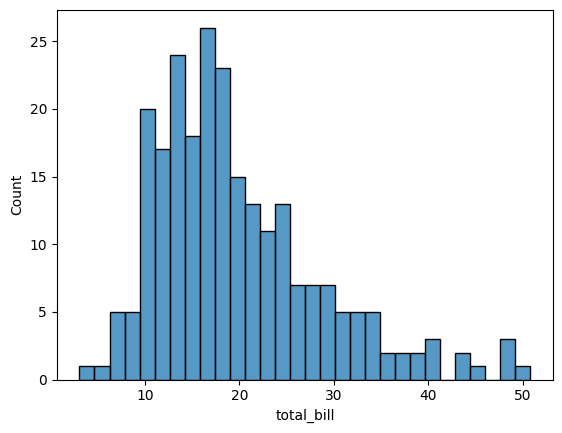

In [7]:
sns.histplot(tips['total_bill'], bins=30, kde=False)  # histogram only

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

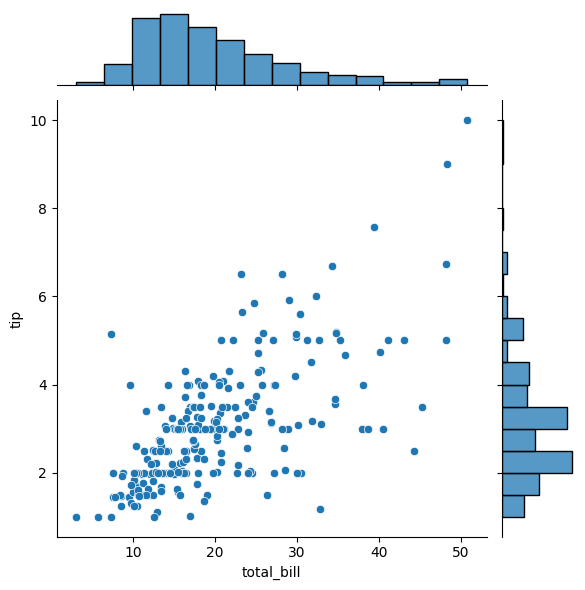

In [9]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='scatter')  # shows a joint plot: scatter between total_bill and tip + hist/KDE on the margins

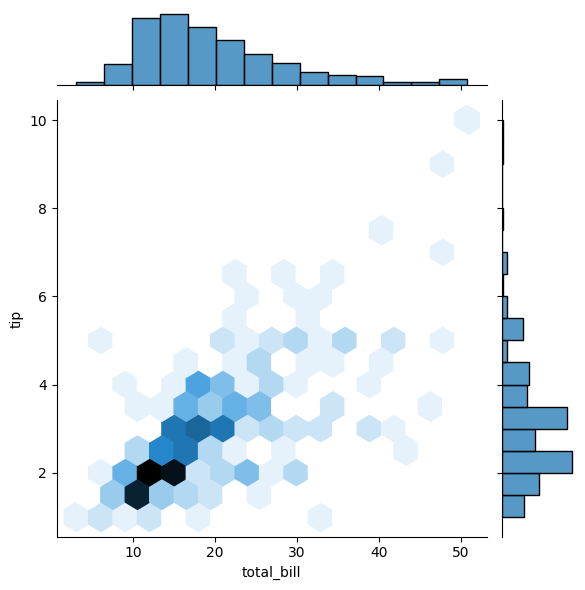

In [10]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex')  # shows a joint plot using hexbin (good when there are many points / overlapping)

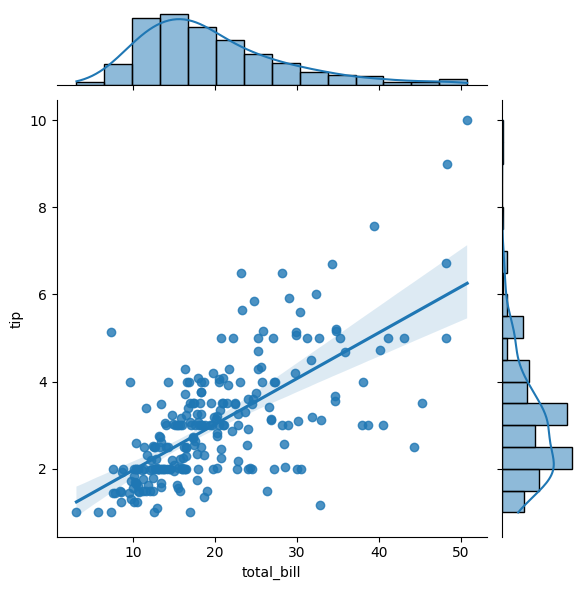

In [11]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')  # shows a joint plot with a regression line fitted to the data

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

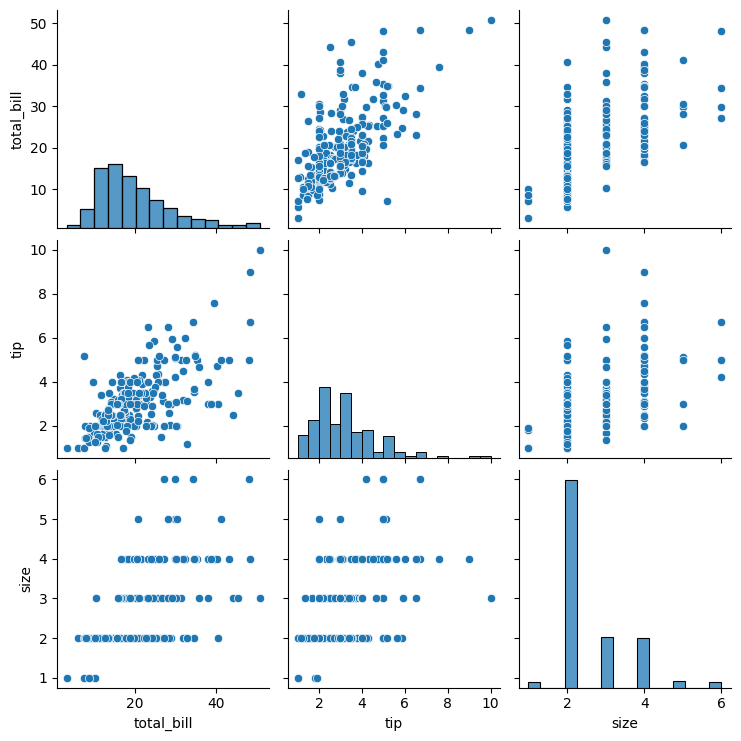

In [12]:
sns.pairplot(tips)  # creates pairwise plots (scatterplots + distributions) for all numeric columns in the tips dataset

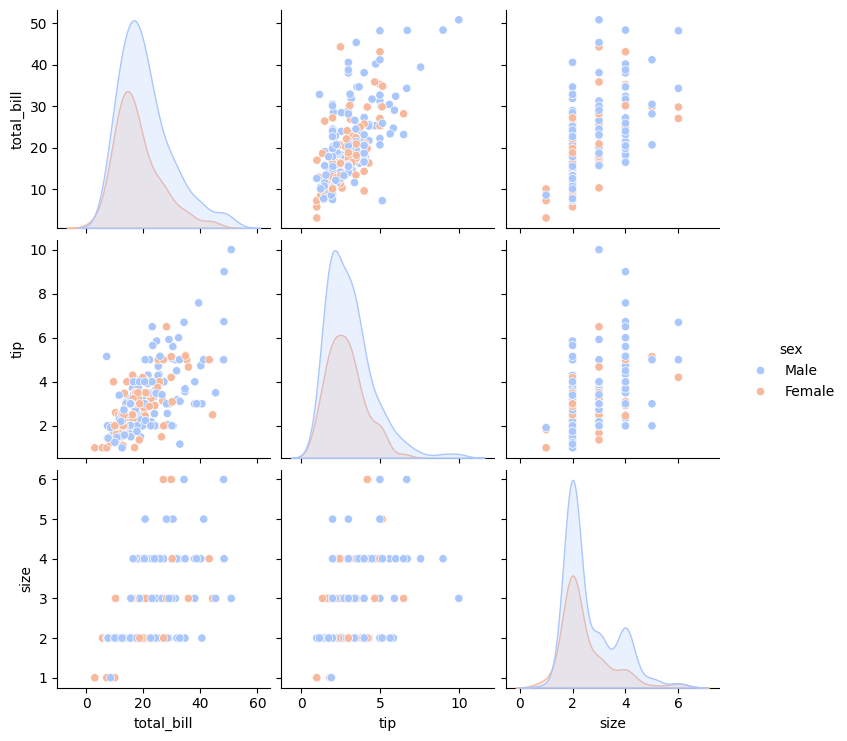

In [13]:
sns.pairplot(tips, hue='sex', palette='coolwarm')  # same pairplot but colors points by the 'sex' category using the coolwarm color palette

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

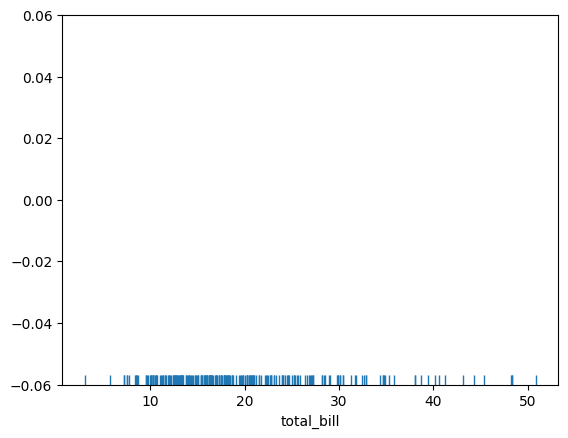

In [14]:
sns.rugplot(tips['total_bill'])  # draws a rug plot (small tick marks) showing each total_bill value along the x-axis

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

(0.0, 1.0)

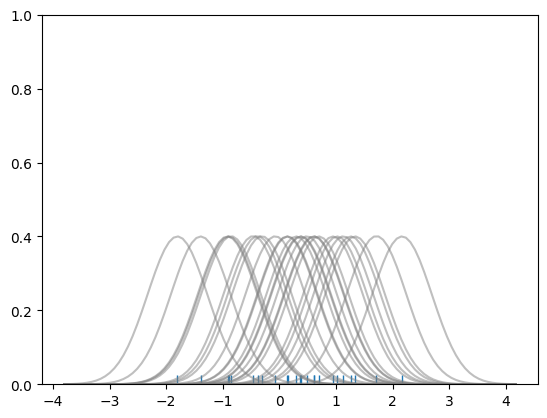

In [22]:
import numpy as np  # imports NumPy for numerical operations and random number generation
import matplotlib.pyplot as plt  # imports Matplotlib for plotting
from scipy import stats  # imports SciPy stats for probability distributions (normal PDF)

# Create dataset
dataset = np.random.randn(25)  # generates 25 random values from a standard normal distribution (mean=0, std=1)

# Create another rugplot
sns.rugplot(dataset)  # draws tick marks for each data point along the x-axis (rug plot)

# Set up the x-axis for the plot
x_min = dataset.min() - 2  # sets the left limit a bit smaller than the minimum value
x_max = dataset.max() + 2  # sets the right limit a bit larger than the maximum value

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min, x_max, 100)  # creates 100 x-values to evaluate/plot the curves

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'  # reference link about KDE bandwidth selection

bandwidth = ((4 * dataset.std()**5) / (3 * len(dataset)))**0.2  # computes KDE bandwidth using a rule-of-thumb formula

# Create an empty kernel list
kernel_list = []  # will store the KDE kernel curves for each data point

# Plot each basis function
for data_point in dataset:  # loops through every value in the dataset

    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point, bandwidth).pdf(x_axis)  # computes a normal PDF centered at data_point with the chosen bandwidth
    kernel_list.append(kernel)  # stores this kernel curve in the list

    # Scale for plotting
    kernel = kernel / kernel.max()  # normalizes the kernel so its peak is 1
    kernel = kernel * 0.4  # scales down the height so multiple kernels fit nicely on the plot
    plt.plot(x_axis, kernel, color='grey', alpha=0.5)  # plots the kernel curve in light grey with transparency

plt.ylim(0, 1)  # sets the y-axis limits from 0 to 1

Text(0.5, 0.98, 'Sum of the Basis Functions')

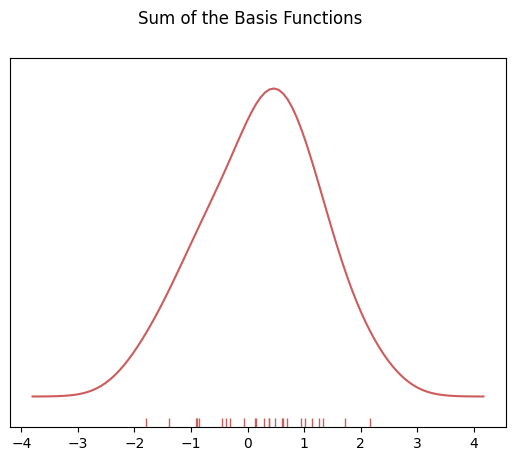

In [23]:
# To get the KDE plot we can sum these basis functions.

# Plot the sum of the basis functions (combine all kernels into one KDE curve)
sum_of_kde = np.sum(kernel_list, axis=0)

# Plot the KDE curve using Matplotlib
fig = plt.plot(x_axis, sum_of_kde, color='indianred')

# Add a rugplot (small ticks) to show the original data points on the x-axis
sns.rugplot(dataset, c='indianred')

# Remove y-axis tick marks (cleaner look)
plt.yticks([])

# Add a main title for the whole figure
plt.suptitle("Sum of the Basis Functions")

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

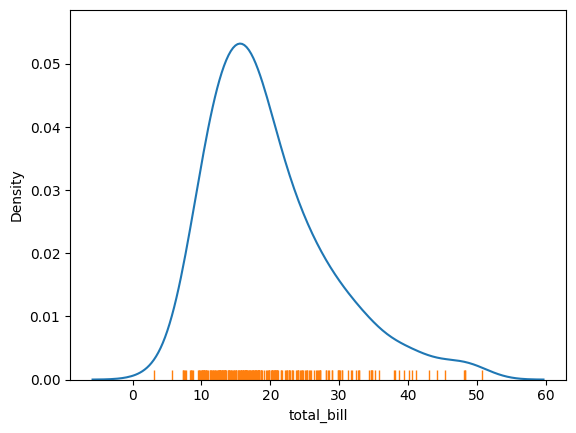

In [24]:
# Draw a KDE (smooth density curve) for the total_bill column
sns.kdeplot(tips['total_bill'])

# Draw a rugplot (small ticks) to show each data point on the x-axis
sns.rugplot(tips['total_bill'])

<Axes: xlabel='tip', ylabel='Density'>

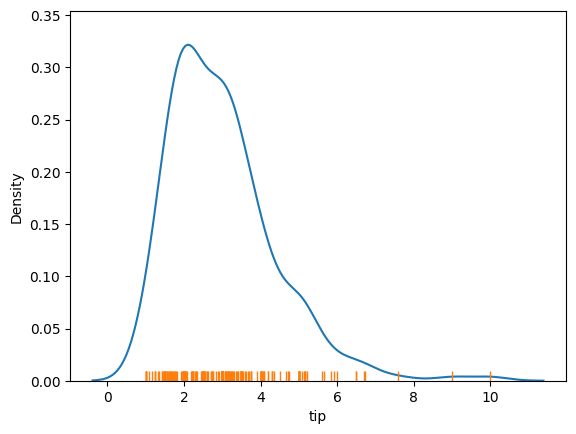

In [25]:
# KDE curve for the tip column
sns.kdeplot(tips['tip'])

# Rugplot for the tip column
sns.rugplot(tips['tip'])

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [26]:
import seaborn as sns  # imports the Seaborn visualization library and gives it the short name sns

%matplotlib inline 
# (Jupyter only) displays plots directly inside the notebook output

In [27]:
tips = sns.load_dataset('tips')   # loads the built-in "tips" dataset into a DataFrame
tips.head()                       # shows the first 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

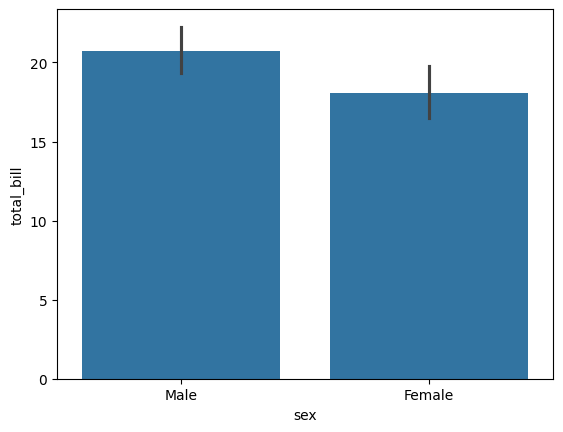

In [28]:
sns.barplot(x='sex', y='total_bill', data=tips)  
# Creates a bar chart using the "tips" dataset:
# - x='sex' groups the data by gender (Male/Female)
# - y='total_bill' is the numeric value being summarized for each group
# By default, seaborn uses the MEAN (average) of total_bill for each sex.


In [29]:
import numpy as np  # Imports NumPy and gives it the short name "np"

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

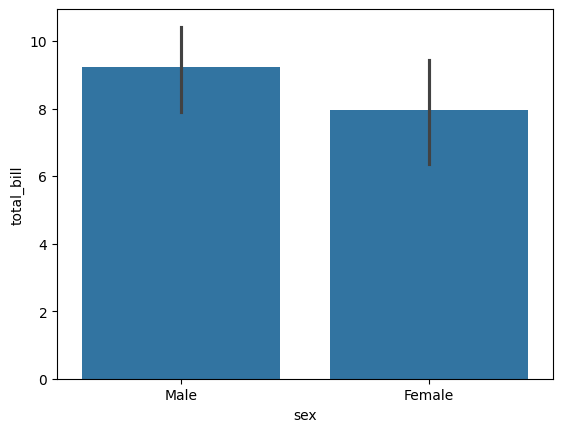

In [30]:
sns.barplot(x='sex', y='total_bill', data=tips, estimator=np.std)  
# Creates a bar chart again, but changes the estimator:
# - estimator=np.std tells seaborn to compute the STANDARD DEVIATION of total_bill
#   for each sex instead of the mean.
# So the height of each bar becomes the standard deviation, not the average.

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

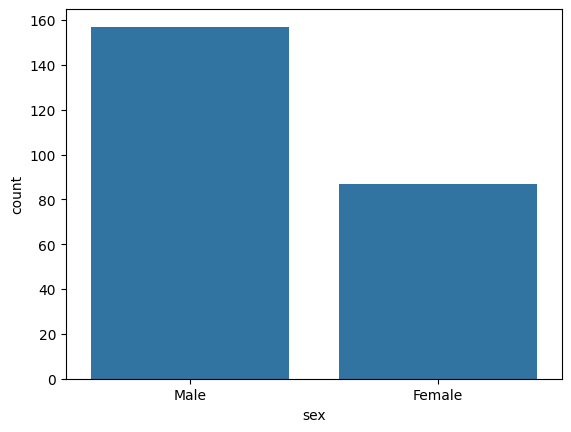

In [31]:
sns.countplot(x='sex', data=tips)  
# Creates a count plot (frequency bar chart):
# - x='sex' groups by gender
# - seaborn counts how many rows/records belong to each sex
# No y is needed because the y-axis is automatically the count.

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

<Axes: xlabel='day', ylabel='total_bill'>

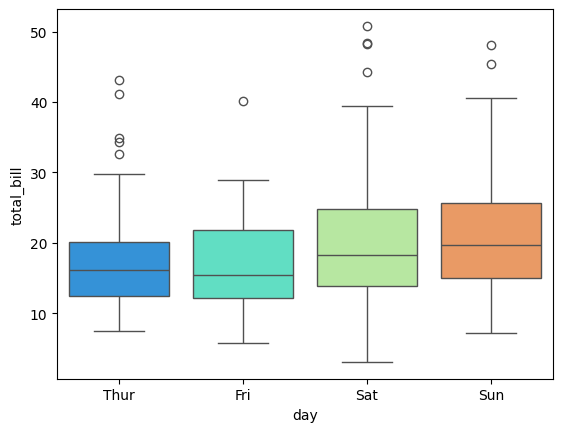

In [33]:
sns.boxplot(x="day", y="total_bill", data=tips, hue="day", palette="rainbow", legend=False)
# Boxplot by day with colors 

<Axes: >

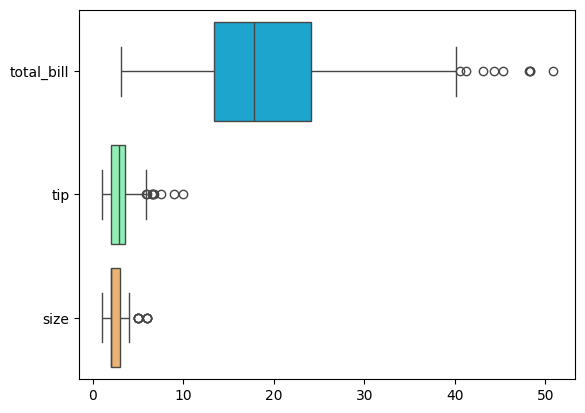

In [34]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips,palette='rainbow',orient='h')

<Axes: xlabel='day', ylabel='total_bill'>

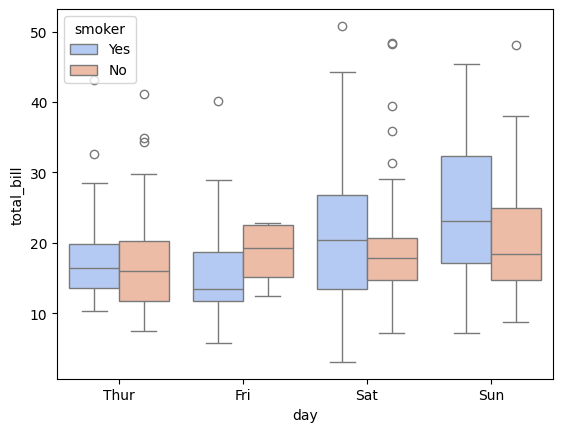

In [35]:
sns.boxplot(x="day", y="total_bill", hue="smoker", data=tips, palette="coolwarm")
# Boxplot of total_bill by day, split by smoker.

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

<Axes: xlabel='day', ylabel='total_bill'>

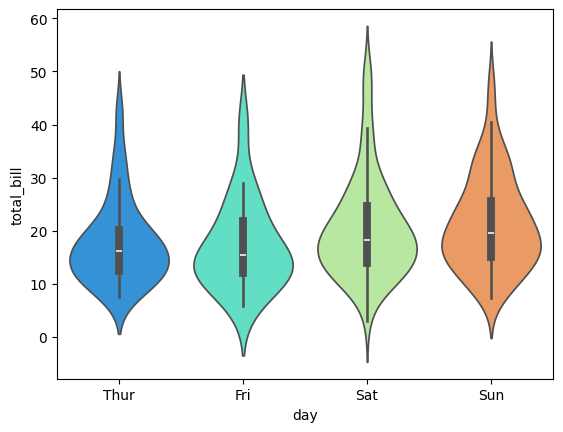

In [39]:
sns.violinplot(x="day", y="total_bill", data=tips, hue="day", palette="rainbow", legend=False)
# Violin plot of total_bill for each day (colored, no warning).

<Axes: xlabel='day', ylabel='total_bill'>

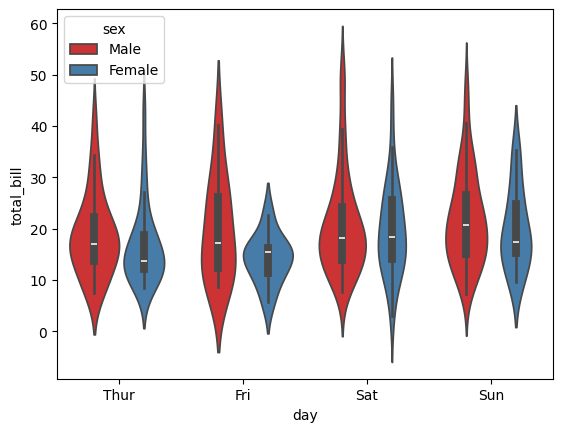

In [40]:
sns.violinplot(x="day", y="total_bill", data=tips, hue="sex", palette="Set1")
# Violin plot by day, colored by sex.

<Axes: xlabel='day', ylabel='total_bill'>

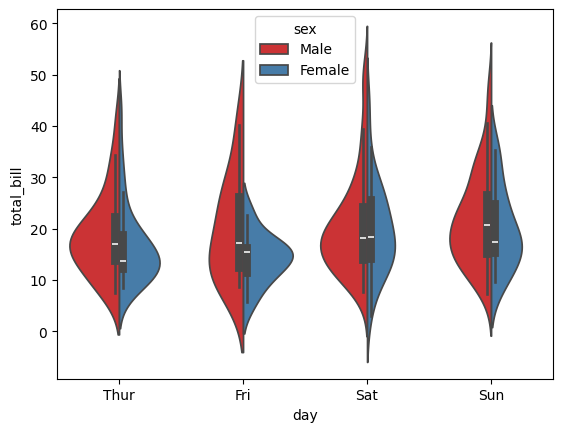

In [41]:
sns.violinplot(x="day", y="total_bill", data=tips, hue="sex", split=True, palette="Set1")
# Split violin plot by day to compare sex in the same violin.

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

<Axes: xlabel='day', ylabel='total_bill'>

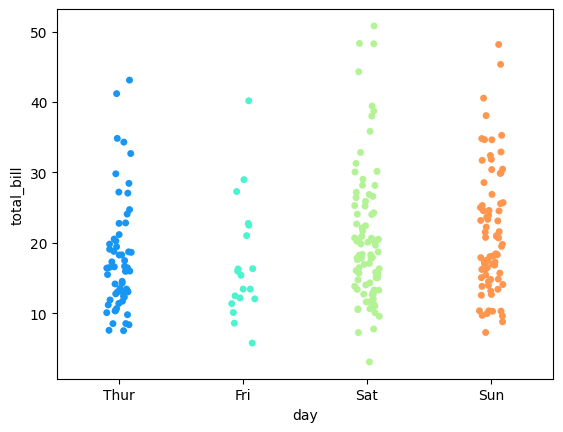

In [43]:
sns.stripplot(x="day", y="total_bill", data=tips, hue="day", palette="rainbow", legend=False)
# Strip plot of total_bill for each day (colored, no warning).

<Axes: xlabel='day', ylabel='total_bill'>

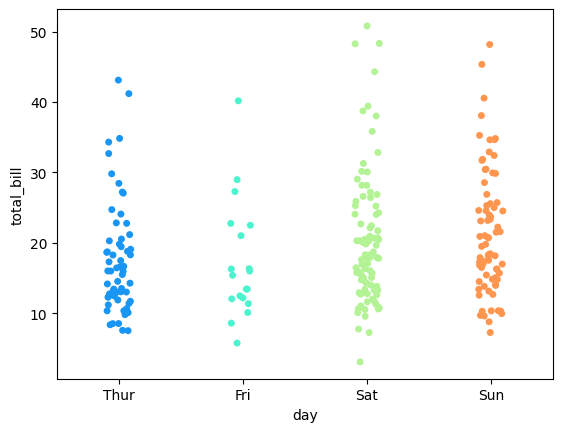

In [45]:
sns.stripplot(x="day", y="total_bill", data=tips, jitter=True, hue="day", palette="rainbow", legend=False)
# Jittered strip plot of total_bill for each day (colored, no warning).

<Axes: xlabel='day', ylabel='total_bill'>

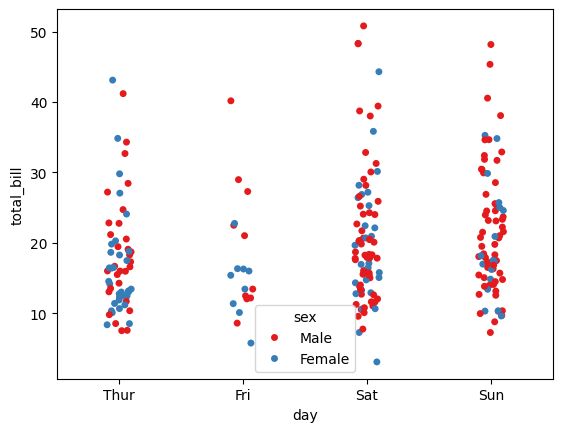

In [46]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1')

<Axes: xlabel='day', ylabel='total_bill'>

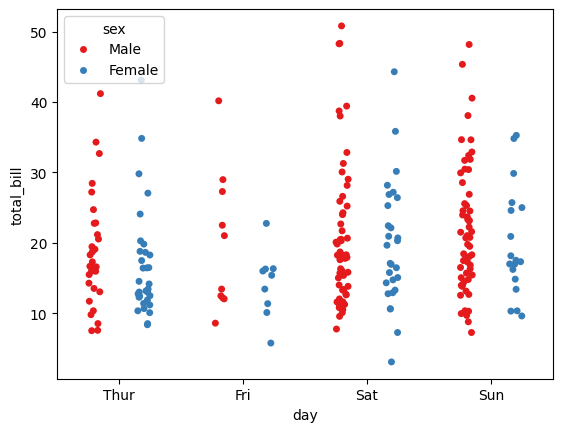

In [47]:
sns.stripplot(x="day", y="total_bill", data=tips, jitter=True, hue='sex', palette='Set1', dodge=True)
# Strip plot by day, split side-by-side by sex.


<Axes: xlabel='day', ylabel='total_bill'>

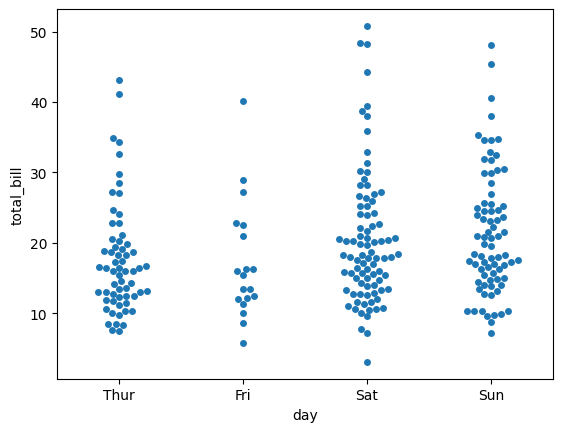

In [49]:
sns.swarmplot(x="day", y="total_bill", data=tips)
# Swarm plot of total_bill for each day (no overlap).

### Combining Categorical Plots

<Axes: xlabel='tip', ylabel='day'>

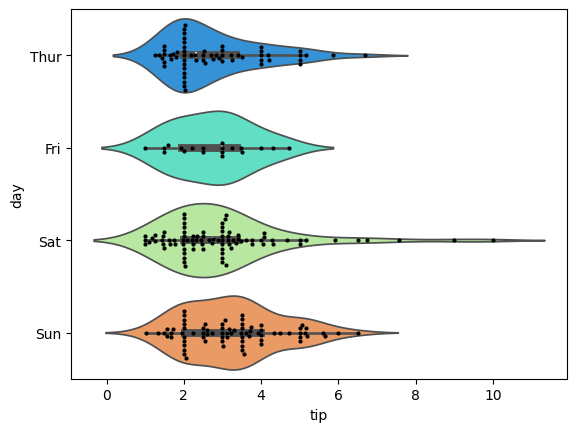

In [51]:
sns.violinplot(x="tip", y="day", data=tips, hue="day", palette="rainbow", legend=False)
# Violin plot of tip by day (colored, no warning).

sns.swarmplot(x="tip", y="day", data=tips, color="black", size=3)
# Swarm plot points on top of the violin plot.

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

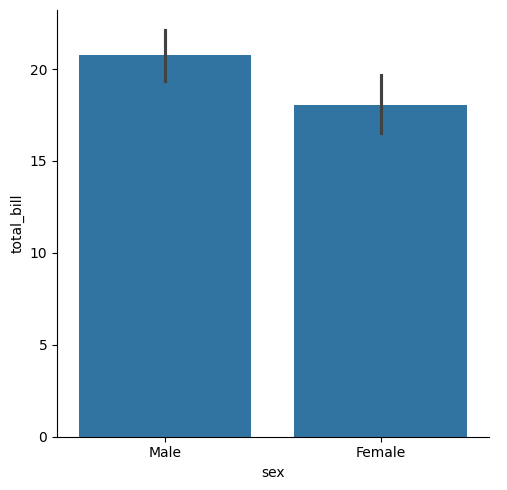

In [53]:
sns.catplot(x="sex", y="total_bill", data=tips, kind="bar")
# Bar chart of average total_bill for each sex.

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [ ]:
import seaborn as sns  # imports the Seaborn visualization library and gives it the short name sns

%matplotlib inline 
# (Jupyter only) displays plots directly inside the notebook output

In [54]:
flights = sns.load_dataset("flights")
# Load the built-in Seaborn "flights" dataset into a DataFrame named flights.

In [55]:
tips = sns.load_dataset("tips")
# Load the built-in Seaborn "tips" dataset into a DataFrame named tips.

In [56]:
tips.head()
# Show the first 5 rows of the tips dataset.

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [57]:
flights.head()
# Show the first 5 rows of the flights dataset.

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [58]:
tips.head()
# Show the first 5 rows of the tips dataset.

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [60]:
tips.corr(numeric_only=True)
# Correlation matrix for numeric columns only.

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

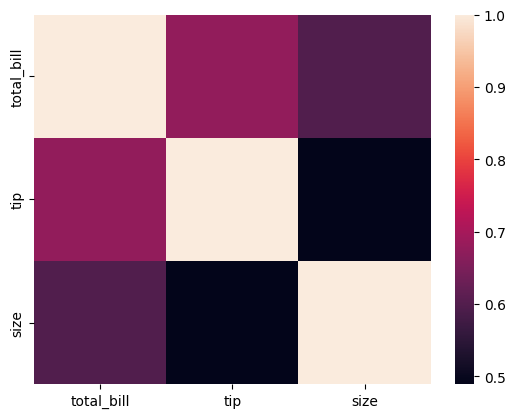

In [62]:
sns.heatmap(tips.corr(numeric_only=True))
# Heatmap of correlation for numeric columns only.

<Axes: >

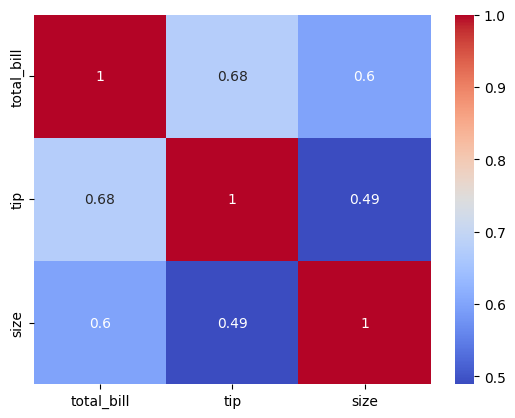

In [63]:
sns.heatmap(tips.corr(numeric_only=True), cmap="coolwarm", annot=True)
# Correlation heatmap for numeric columns (with values shown).

Or for the flights data:

<Axes: xlabel='year', ylabel='month'>

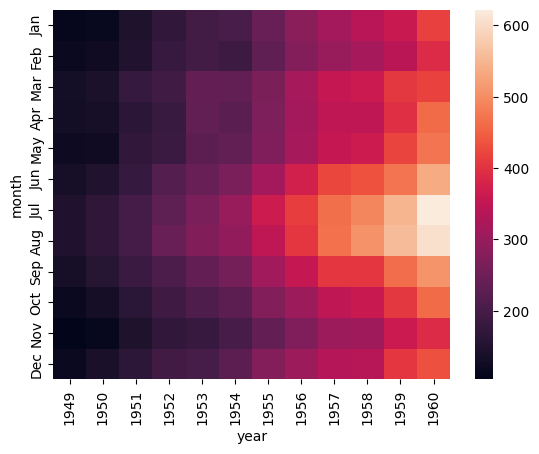

In [68]:
flights = sns.load_dataset("flights")
# Reload the original flights dataset.

pvflights = flights.pivot_table(values="passengers", index="month", columns="year", observed=False)
# Create the pivot table (no warning).

sns.heatmap(pvflights)
# Heatmap of the pivot table.

<Axes: xlabel='year', ylabel='month'>

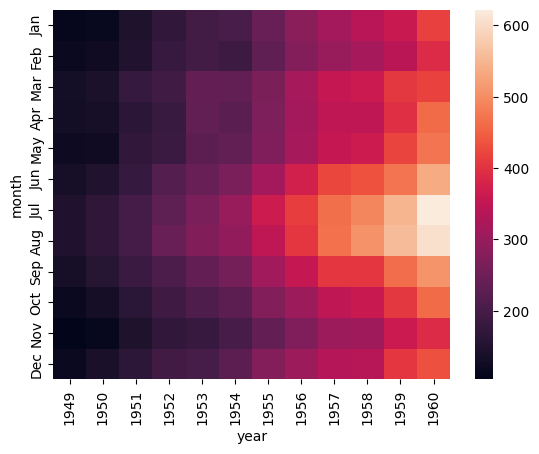

In [69]:
flights = flights.pivot_table(values="passengers", index="month", columns="year", observed=False)
# Pivot table of passengers (keeps current pandas behavior; no warning).

sns.heatmap(flights)
# Heatmap of the pivot table.

<Axes: xlabel='year', ylabel='month'>

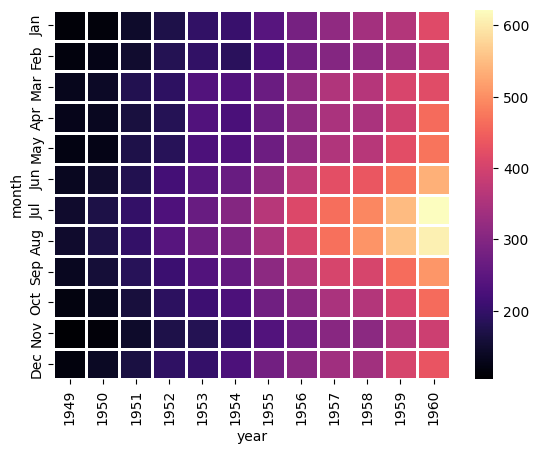

In [70]:
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1)

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

<Axes: xlabel='year', ylabel='month'>

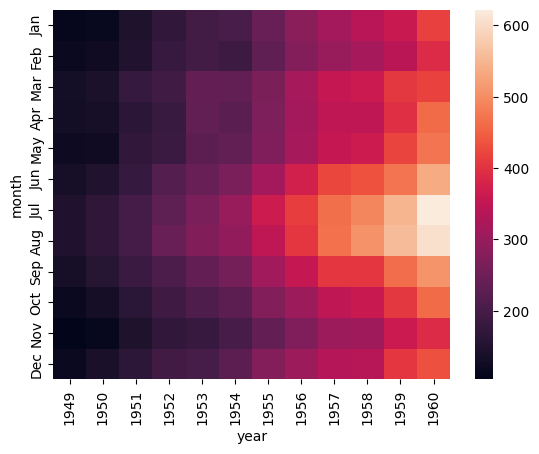

In [76]:
sns.heatmap(pvflights)
# Regular heatmap (no SciPy needed).

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [77]:
tips = sns.load_dataset("tips")
# Load the built-in Seaborn "tips" dataset into a DataFrame named tips.

In [78]:
tips.head()
# Show the first 5 rows of the tips dataset.

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

In [ ]:
sns.lmplot(x="total_bill", y="tip", data=tips)
# Scatter plot of total_bill vs tip with a fitted regression line.

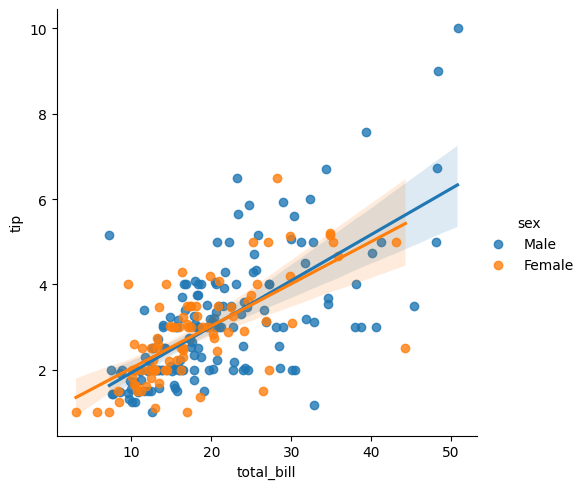

In [79]:
sns.lmplot(x="total_bill", y="tip", data=tips, hue="sex")
# Regression plot of total_bill vs tip, separated by sex.

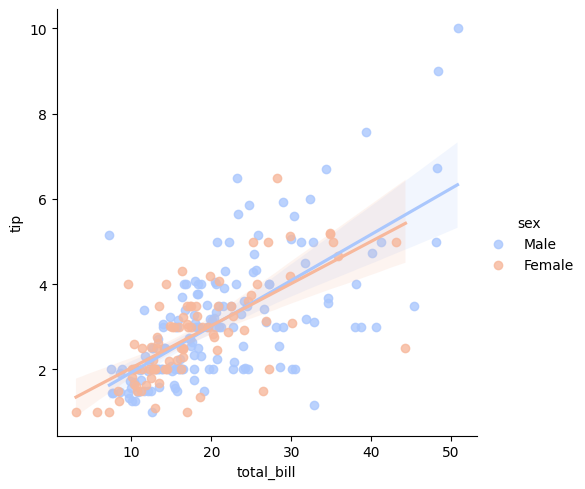

In [80]:
sns.lmplot(x="total_bill", y="tip", data=tips, hue="sex", palette="coolwarm")
# Regression plot of total_bill vs tip, colored by sex.

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

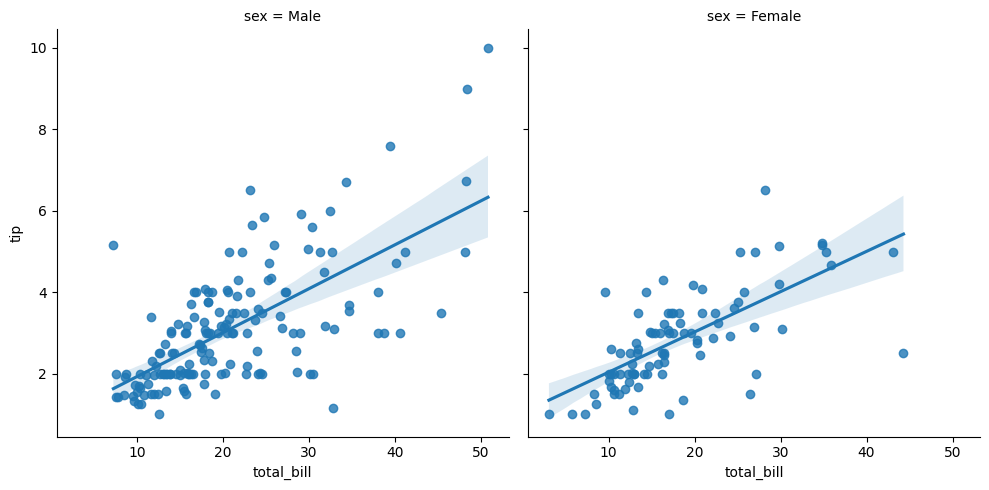

In [81]:
sns.lmplot(x="total_bill", y="tip", data=tips, col="sex")
# Separate regression plots of total_bill vs tip for each sex (one column per sex).

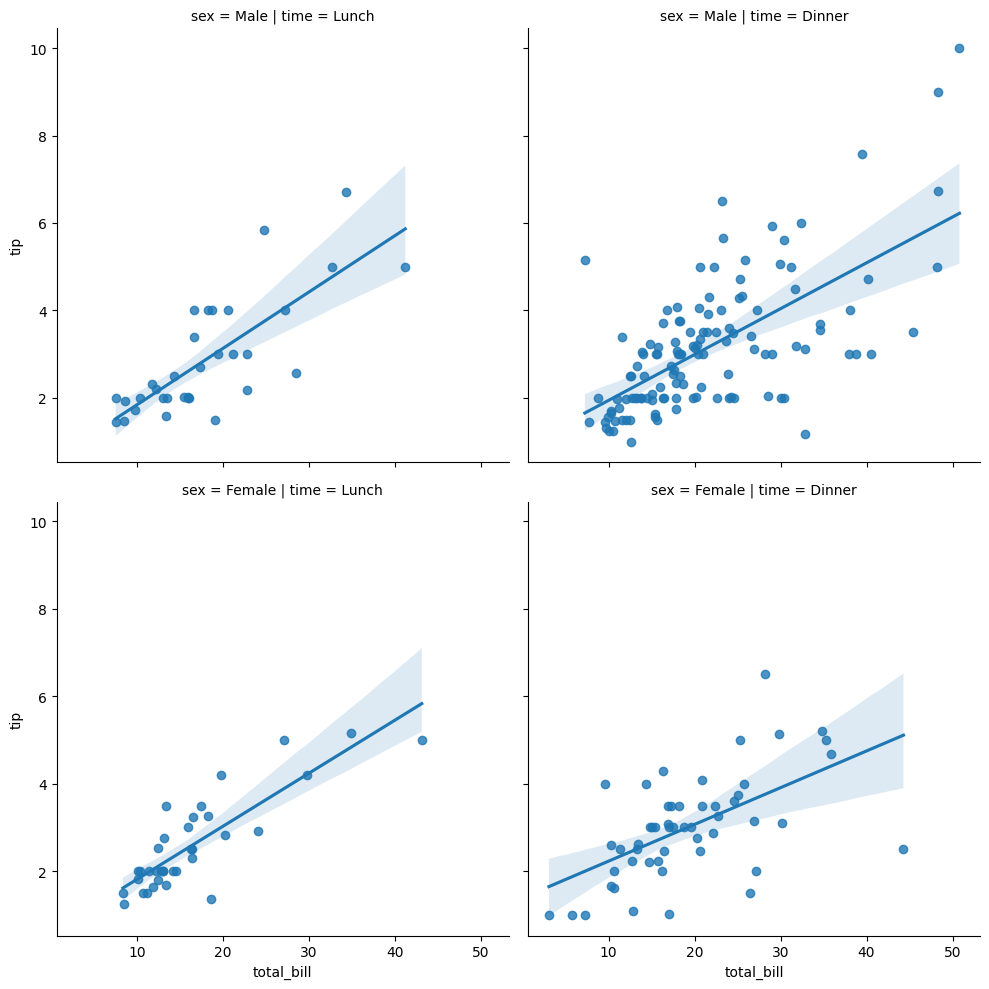

In [82]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time", data=tips)
# Regression plots split by sex (rows) and time (columns).

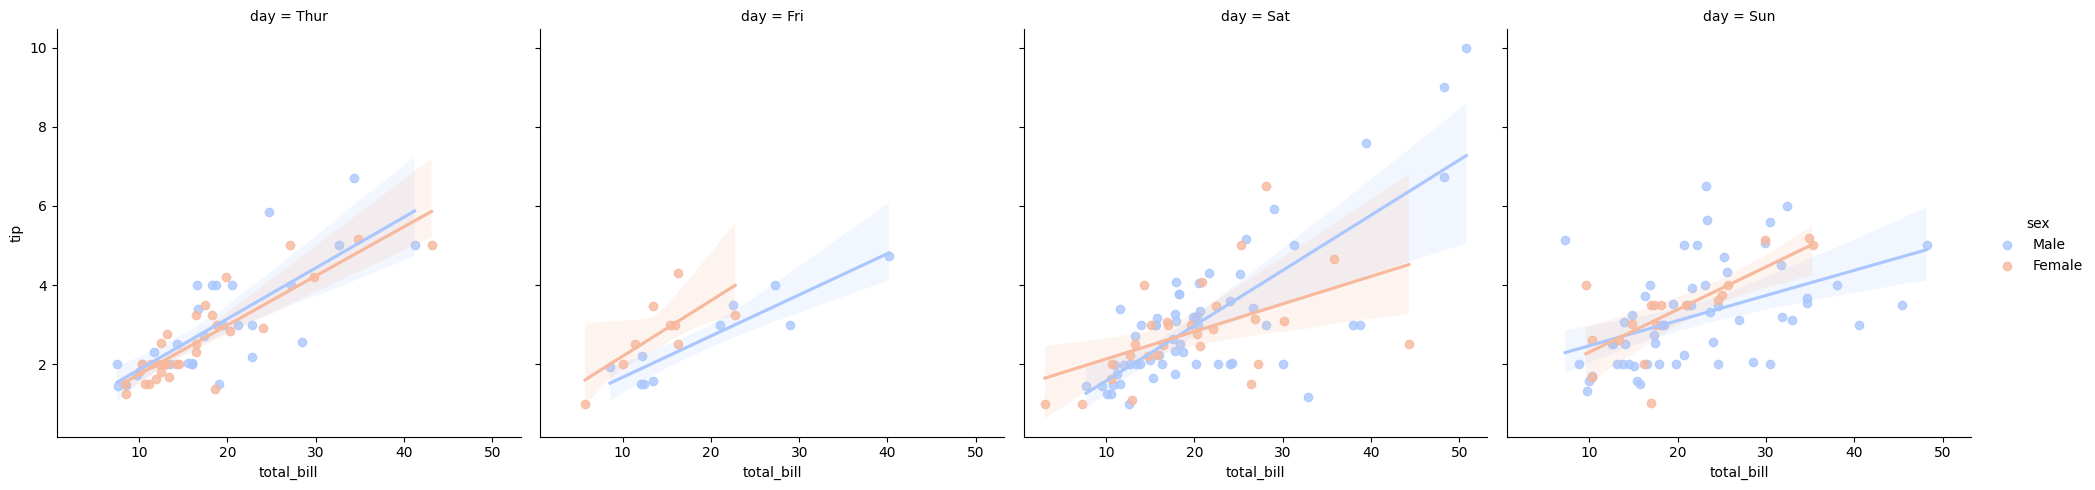

In [83]:
sns.lmplot(x="total_bill", y="tip", data=tips, col="day", hue="sex", palette="coolwarm")
# Regression plots by day, colored by sex.

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

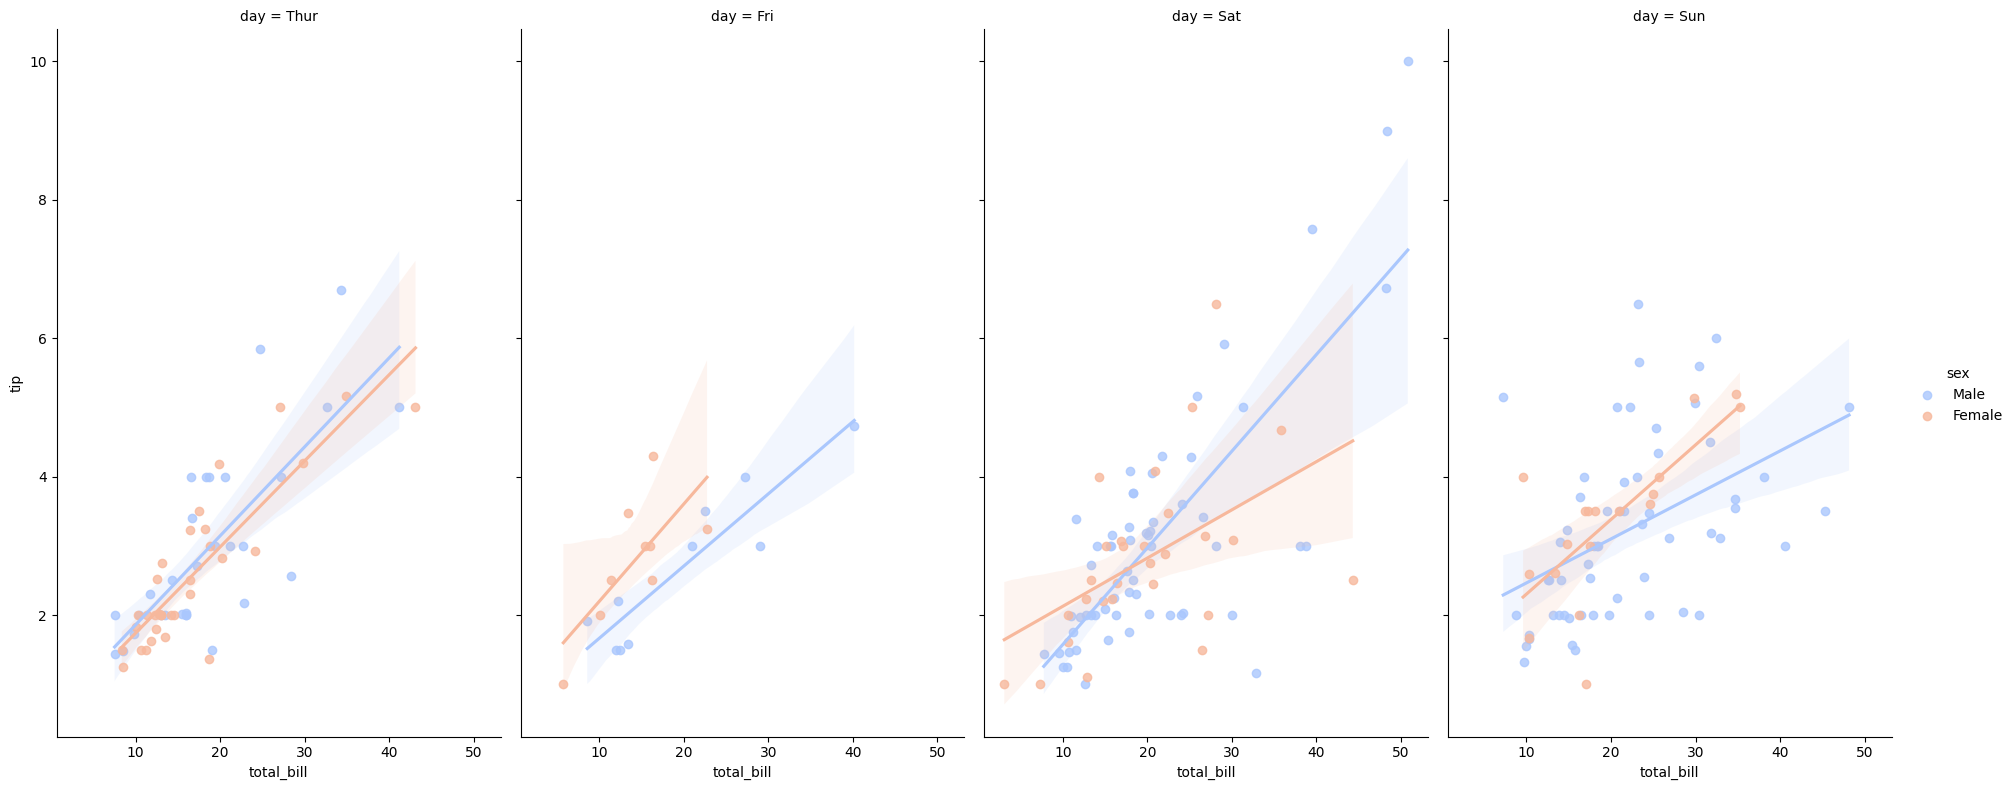

In [84]:
sns.lmplot(x="total_bill", y="tip", data=tips, col="day", hue="sex",
           palette="coolwarm", aspect=0.6, height=8)
# Regression plots by day, colored by sex, with custom plot size/shape.

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes